# Random Forest Housing Model

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.figsize'] = (8,5)


In [2]:
train_fp = Path('final_training.csv')
test_fp = Path('oct_testing.csv')

df_train = pd.read_csv(train_fp, sep='\t' if '\t' in open(train_fp).read(1024) else ',', engine='python')
df_test = pd.read_csv(test_fp, sep='\t' if '\t' in open(test_fp).read(1024) else ',', engine='python')

print('train shape:', df_train.shape)
print('test shape:', df_test.shape)

df_train.head()

train shape: (88920, 23)
test shape: (4864, 23)


,ViewYN,PoolPrivateYN,CloseDate,ClosePrice,Latitude,Longitude,LivingArea,CountyOrParish,AttachedGarageYN,ParkingTotal,...,BedroomsTotal,ContractStatusChangeDate,PurchaseContractDate,ListingContractDate,FireplaceYN,Stories,NewConstructionYN,GarageSpaces,PostalCode,PropertyAgeAtClose
0,False,False,2025-02-11,875000.0,32.765380,-117.043486,2340.0,San Diego,True,6.0,...,4.0,2025-02-11,2021-01-25,2021-01-05,False,1.0,False,2.0,91942,4.0
1,False,False,2025-02-14,875000.0,32.765038,-117.043568,2165.0,San Diego,True,4.0,...,5.0,2025-02-14,2021-01-14,2021-01-05,False,1.0,False,2.0,91942,4.0
2,False,False,2025-02-18,849000.0,32.765031,-117.043252,2158.0,San Diego,True,4.0,...,4.0,2025-02-18,2021-01-25,2020-10-22,False,1.0,False,2.0,91942,4.0
3,True,False,2025-02-28,1100000.0,33.724000,-118.294924,2545.0,Los Angeles,False,3.0,...,4.0,2025-02-28,2025-01-10,2024-11-18,True,2.0,False,2.0,90731,63.0
4,False,False,2025-02-28,760000.0,37.687556,-122.150114,1692.0,Alameda,True,2.0,...,4.0,2025-02-28,2025-02-28,2025-02-28,True,1.0,False,2.0,94579,75.0


--- TRAIN ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88920 entries, 0 to 88919
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ViewYN                    88920 non-null  bool   
 1   PoolPrivateYN             88920 non-null  bool   
 2   CloseDate                 88920 non-null  object 
 3   ClosePrice                88920 non-null  float64
 4   Latitude                  88920 non-null  float64
 5   Longitude                 88920 non-null  float64
 6   LivingArea                88920 non-null  float64
 7   CountyOrParish            88920 non-null  object 
 8   AttachedGarageYN          88920 non-null  bool   
 9   ParkingTotal              88920 non-null  float64
 10  YearBuilt                 88920 non-null  float64
 11  BathroomsTotalInteger     88920 non-null  float64
 12  City                      88920 non-null  object 
 13  BedroomsTotal             88920 non-null  float

None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ViewYN,88920,2,True,49232,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PoolPrivateYN,88920,2,False,74975,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CloseDate,88920,240,2025-06-20,836,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ClosePrice,88920.0,NaN,NaN,NaN,1204628.575309,966003.516602,190000.0,630000.0,899000.0,1429006.25,8500000.0
Latitude,88920.0,NaN,NaN,NaN,34.73254,1.715307,0.0,33.760679,34.080067,34.755353,41.894714
Longitude,88920.0,NaN,NaN,NaN,-118.6184,3.050863,-124.193201,-119.159296,-118.026054,-117.26151,329.0
LivingArea,88920.0,NaN,NaN,NaN,2021.562304,941.420958,0.0,1386.0,1812.0,2421.0,14168.0
CountyOrParish,88920,57,Los Angeles,22183,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AttachedGarageYN,88920,2,True,65639,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ParkingTotal,88920.0,NaN,NaN,NaN,3.196294,63.57319,-35.0,2.0,2.0,3.0,15720.0



--- TEST ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4864 entries, 0 to 4863
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ViewYN                    4864 non-null   bool   
 1   PoolPrivateYN             4864 non-null   bool   
 2   CloseDate                 4864 non-null   object 
 3   ClosePrice                4864 non-null   float64
 4   Latitude                  4864 non-null   float64
 5   Longitude                 4864 non-null   float64
 6   LivingArea                4864 non-null   float64
 7   CountyOrParish            4864 non-null   object 
 8   AttachedGarageYN          4864 non-null   bool   
 9   ParkingTotal              4864 non-null   float64
 10  YearBuilt                 4864 non-null   float64
 11  BathroomsTotalInteger     4864 non-null   float64
 12  City                      4864 non-null   object 
 13  BedroomsTotal             4864 non-null   float64

None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ViewYN,4864,2,True,2737,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PoolPrivateYN,4864,2,False,4119,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CloseDate,4864,28,2025-10-24,502,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ClosePrice,4864.0,NaN,NaN,NaN,1254029.500598,917950.247339,239000.0,680085.5,944975.0,1506250.0,6350000.0
Latitude,4864.0,NaN,NaN,NaN,34.591052,1.58425,32.562673,33.765953,34.058897,34.435057,40.448208
Longitude,4864.0,NaN,NaN,NaN,-118.541027,2.324108,-123.809556,-118.753956,-118.034673,-117.285354,-11.230259
LivingArea,4864.0,NaN,NaN,NaN,2046.602385,933.349215,0.0,1404.75,1832.5,2460.5,12680.0
CountyOrParish,4864,40,Los Angeles,1381,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AttachedGarageYN,4864,2,True,3448,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ParkingTotal,4864.0,NaN,NaN,NaN,2.981908,9.587867,-12.0,2.0,2.0,3.0,502.0


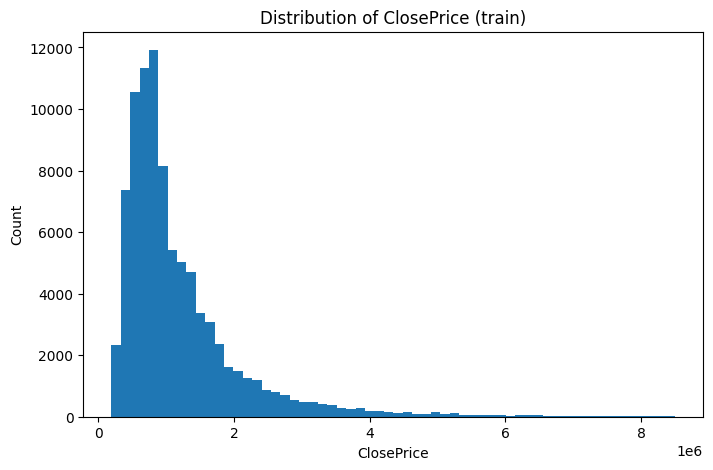

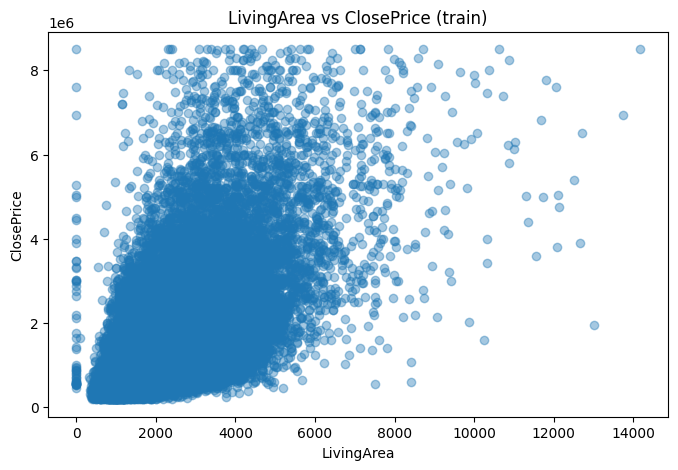

In [3]:
# EDA
print('--- TRAIN ---')
display(df_train.info())
display(df_train.describe(include='all').T)

print('\n--- TEST ---')
display(df_test.info())
display(df_test.describe(include='all').T)

# Visual: ClosePrice distribution (train)
plt.figure()
plt.hist(df_train['ClosePrice'].dropna(), bins=60)
plt.title('Distribution of ClosePrice (train)')
plt.xlabel('ClosePrice')
plt.ylabel('Count')
plt.show()

# Scatter: LivingArea vs ClosePrice
plt.figure()
plt.scatter(df_train['LivingArea'], df_train['ClosePrice'], alpha=0.4)
plt.title('LivingArea vs ClosePrice (train)')
plt.xlabel('LivingArea')
plt.ylabel('ClosePrice')
plt.show()


In [4]:
# Feature engineering
def prepare(df, is_train=True, top_cities=12):
    df = df.copy()
    # Parse dates
    for c in ['CloseDate','ContractStatusChangeDate','PurchaseContractDate','ListingContractDate']:
        if c in df.columns:
            df[c] = pd.to_datetime(df[c], errors='coerce')
    # Simple date diffs
    if 'ListingContractDate' in df.columns and 'CloseDate' in df.columns:
        df['days_listing_to_close'] = (df['CloseDate'] - df['ListingContractDate']).dt.days
    if 'PurchaseContractDate' in df.columns and 'CloseDate' in df.columns:
        df['days_purchase_to_close'] = (df['CloseDate'] - df['PurchaseContractDate']).dt.days
    # Year-based features
    if 'YearBuilt' in df.columns and 'CloseDate' in df.columns:
        df['year_closed'] = df['CloseDate'].dt.year
        df['age_at_close_calc'] = df['year_closed'] - df['YearBuilt']
    # Fill/convert boolean-like columns
    bool_cols = [c for c in df.columns if c.endswith('YN') or c in ['AttachedGarageYN','FireplaceYN','NewConstructionYN','ViewYN','PoolPrivateYN']]
    for c in bool_cols:
        if c in df.columns:
            df[c] = df[c].map({True:1, False:0}).fillna(0).astype(int)
    # PostalCode as string
    if 'PostalCode' in df.columns:
        df['PostalCode'] = df['PostalCode'].astype(str)
    # City frequency encoding for many cities -> keep top N, rest 'Other'
    if 'City' in df.columns:
        top = df['City'].value_counts().nlargest(top_cities).index
        df['City_top'] = df['City'].where(df['City'].isin(top), other='Other')
    # Garage spaces to numeric
    if 'GarageSpaces' in df.columns:
        df['GarageSpaces'] = pd.to_numeric(df['GarageSpaces'], errors='coerce').fillna(0)
    # Basic interaction
    if 'BedroomsTotal' in df.columns and 'BathroomsTotalInteger' in df.columns:
        df['beds_baths'] = df['BedroomsTotal'] * df['BathroomsTotalInteger']
    return df

df_train_p = prepare(df_train, is_train=True)
df_test_p = prepare(df_test, is_train=False)

print('train prepared shape', df_train_p.shape)
df_train_p.head()

train prepared shape (88920, 29)


,ViewYN,PoolPrivateYN,CloseDate,ClosePrice,Latitude,Longitude,LivingArea,CountyOrParish,AttachedGarageYN,ParkingTotal,...,NewConstructionYN,GarageSpaces,PostalCode,PropertyAgeAtClose,days_listing_to_close,days_purchase_to_close,year_closed,age_at_close_calc,City_top,beds_baths
0,0,0,2025-02-11,875000.0,32.765380,-117.043486,2340.0,San Diego,1,6.0,...,0,2.0,91942,4.0,1498,1478,2025,4.0,Other,16.0
1,0,0,2025-02-14,875000.0,32.765038,-117.043568,2165.0,San Diego,1,4.0,...,0,2.0,91942,4.0,1501,1492,2025,4.0,Other,20.0
2,0,0,2025-02-18,849000.0,32.765031,-117.043252,2158.0,San Diego,1,4.0,...,0,2.0,91942,4.0,1580,1485,2025,4.0,Other,12.0
3,1,0,2025-02-28,1100000.0,33.724000,-118.294924,2545.0,Los Angeles,0,3.0,...,0,2.0,90731,63.0,102,49,2025,63.0,Other,12.0
4,0,0,2025-02-28,760000.0,37.687556,-122.150114,1692.0,Alameda,1,2.0,...,0,2.0,94579,75.0,0,0,2025,75.0,Other,8.0


In [5]:
# Select features and target
target = 'ClosePrice'
# Candidate features (auto-detect numeric + top categorical)
numeric_feats = ['LivingArea','BedroomsTotal','BathroomsTotalInteger','GarageSpaces','ParkingTotal','PropertyAgeAtClose','year_closed','age_at_close_calc','days_listing_to_close','days_purchase_to_close','beds_baths']
numeric_feats = [c for c in numeric_feats if c in df_train_p.columns]

cat_feats = ['City_top','CountyOrParish','PostalCode']
cat_feats = [c for c in cat_feats if c in df_train_p.columns]

# logical binary columns
bin_feats = [c for c in df_train_p.columns if c.endswith('YN') or c in ['AttachedGarageYN','FireplaceYN','NewConstructionYN','ViewYN','PoolPrivateYN']]
bin_feats = [c for c in bin_feats if c in df_train_p.columns]

features = numeric_feats + cat_feats + bin_feats
print('Using features:', features)

X_train = df_train_p[features].copy()
y_train = df_train_p[target].copy()

X_test = df_test_p[features].copy()
y_test = df_test_p[target].copy() if target in df_test_p.columns else None

# Preprocessing pipelines
num_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale', StandardScaler())
])

cat_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, numeric_feats),
    ('cat', cat_pipeline, cat_feats)
], remainder='passthrough')  # keep binary features as-is

# Fit transform to inspect shapes
X_train_trans = preprocessor.fit_transform(X_train)
X_test_trans = preprocessor.transform(X_test)

print('X_train_trans shape:', X_train_trans.shape)
print('X_test_trans shape:', X_test_trans.shape)


Using features: ['LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger', 'GarageSpaces', 'ParkingTotal', 'PropertyAgeAtClose', 'year_closed', 'age_at_close_calc', 'days_listing_to_close', 'days_purchase_to_close', 'beds_baths', 'City_top', 'CountyOrParish', 'PostalCode', 'ViewYN', 'PoolPrivateYN', 'AttachedGarageYN', 'FireplaceYN', 'NewConstructionYN']
X_train_trans shape: (88920, 1890)
X_test_trans shape: (4864, 1890)


In [6]:
rf = RandomForestRegressor(
    n_estimators=150,     # balanced speed + accuracy
    max_depth=18,         # avoids overfitting and speeds up splits
    min_samples_split=4,  # faster/smoother trees
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=42
)

model = Pipeline([
    ('pre', preprocessor),
    ('rf', rf)
])

model.fit(X_train, y_train)

print("Done training!")
best_model = model 


Done training!


Test RMSE: 463173.73
Test MAE: 278059.95
Test R2: 0.745


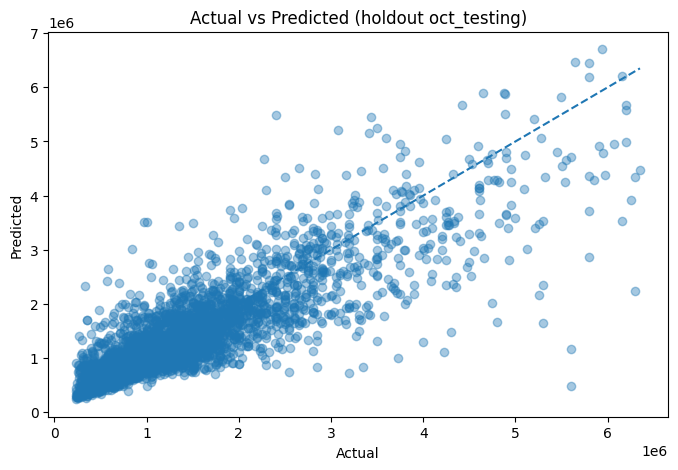

In [7]:
# Evaluation on the test set (oct_testing)
preds_test = best_model.predict(X_test)
def eval_scatter(y_true, y_pred, title=''):
    plt.figure()
    plt.scatter(y_true, y_pred, alpha=0.4)
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], linestyle='--')
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.title(title)
    plt.show()

if y_test is not None:
    rmse = mean_squared_error(y_test, preds_test) ** 0.5
    mae = mean_absolute_error(y_test, preds_test)
    r2 = r2_score(y_test, preds_test)
    print(f'Test RMSE: {rmse:.2f}')
    print(f'Test MAE: {mae:.2f}')
    print(f'Test R2: {r2:.3f}')
    eval_scatter(y_test, preds_test, 'Actual vs Predicted (holdout oct_testing)')
else:
    print('No ClosePrice in oct_testing to evaluate against; showing predictions head:')
    display(preds_test[:10])


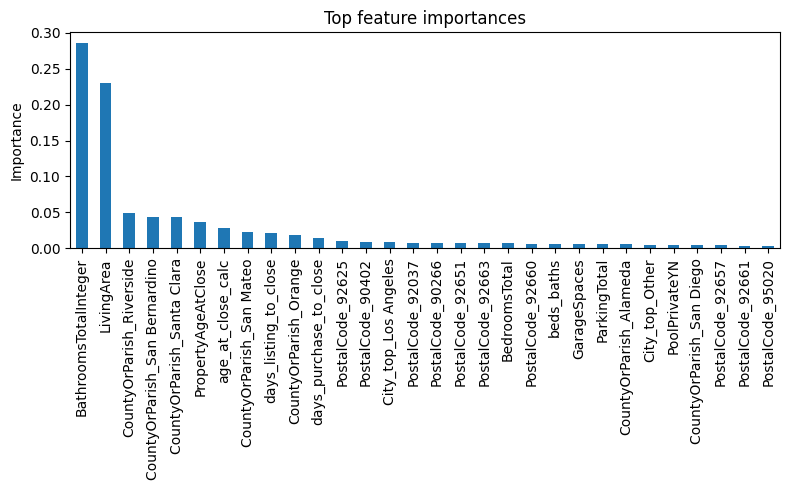

BathroomsTotalInteger            0.286294
LivingArea                       0.230440
CountyOrParish_Riverside         0.049143
CountyOrParish_San Bernardino    0.043220
CountyOrParish_Santa Clara       0.043097
PropertyAgeAtClose               0.036327
age_at_close_calc                0.028565
CountyOrParish_San Mateo         0.022091
days_listing_to_close            0.021364
CountyOrParish_Orange            0.018718
days_purchase_to_close           0.013782
PostalCode_92625                 0.009650
PostalCode_90402                 0.008588
City_top_Los Angeles             0.008201
PostalCode_92037                 0.007901
PostalCode_90266                 0.007862
PostalCode_92651                 0.007701
PostalCode_92663                 0.007313
BedroomsTotal                    0.006942
PostalCode_92660                 0.006514
beds_baths                       0.005825
GarageSpaces                     0.005605
ParkingTotal                     0.005505
CountyOrParish_Alameda           0

In [8]:
# Feature importance (approximate) - extract numeric & onehot feature names
# We need to build names for preprocessor output
num_names = numeric_feats
# categories from the fitted OneHotEncoder
cat_names = []
if 'cat' in best_model.named_steps['pre'].named_transformers_:
    ohe = best_model.named_steps['pre'].named_transformers_['cat'].named_steps['onehot']
    if hasattr(ohe, 'get_feature_names_out'):
        cat_names = list(ohe.get_feature_names_out(cat_feats))
# remainder (binary) names preserved by 'remainder' passthrough
remainder_names = bin_feats

all_feature_names = num_names + cat_names + remainder_names

importances = best_model.named_steps['rf'].feature_importances_
# Align length if mismatch
if len(importances) > len(all_feature_names):
    # possible because OneHotEncoder sparse=False output shape; trim to length
    importances = importances[:len(all_feature_names)]

feat_imp = pd.Series(importances, index=all_feature_names).sort_values(ascending=False).head(30)
plt.figure()
feat_imp.plot(kind='bar')
plt.title('Top feature importances')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

display(feat_imp)


In [9]:
# Save predictions to CSV alongside ID columns if present
out = df_test.copy()
out['PredictedClosePrice'] = preds_test
out_fp = Path('oct_testing_with_preds.csv')
out.to_csv(out_fp, index=False)
print('Saved predictions to', out_fp)


Saved predictions to oct_testing_with_preds.csv


---

**Notes & next steps**

- Try more advanced feature engineering (geospatial clusters from lat/lon, polynomial interactions, target encoding for City/PostalCode, use of temporal features).